
Model saved successfully!
File: isolation_forest_model.joblib

       ISOLATION FOREST RESULTS
Number of observations: 3497
Detected anomalies: 105
Anomaly rate: 3.0 %


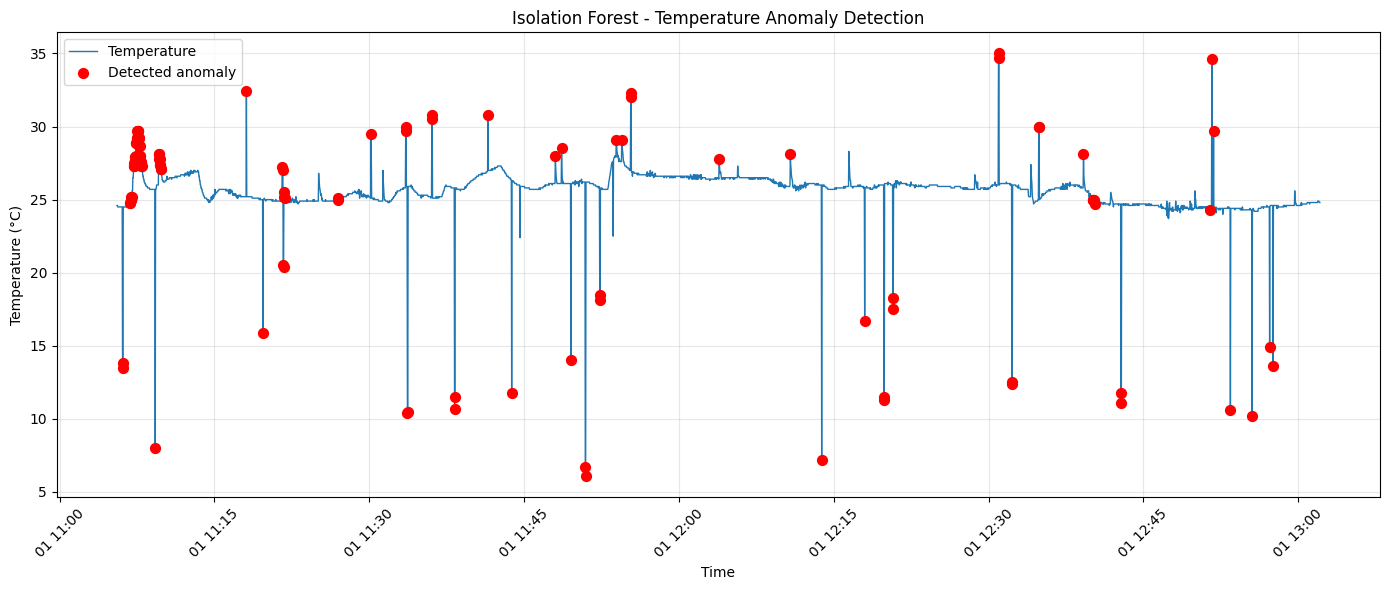

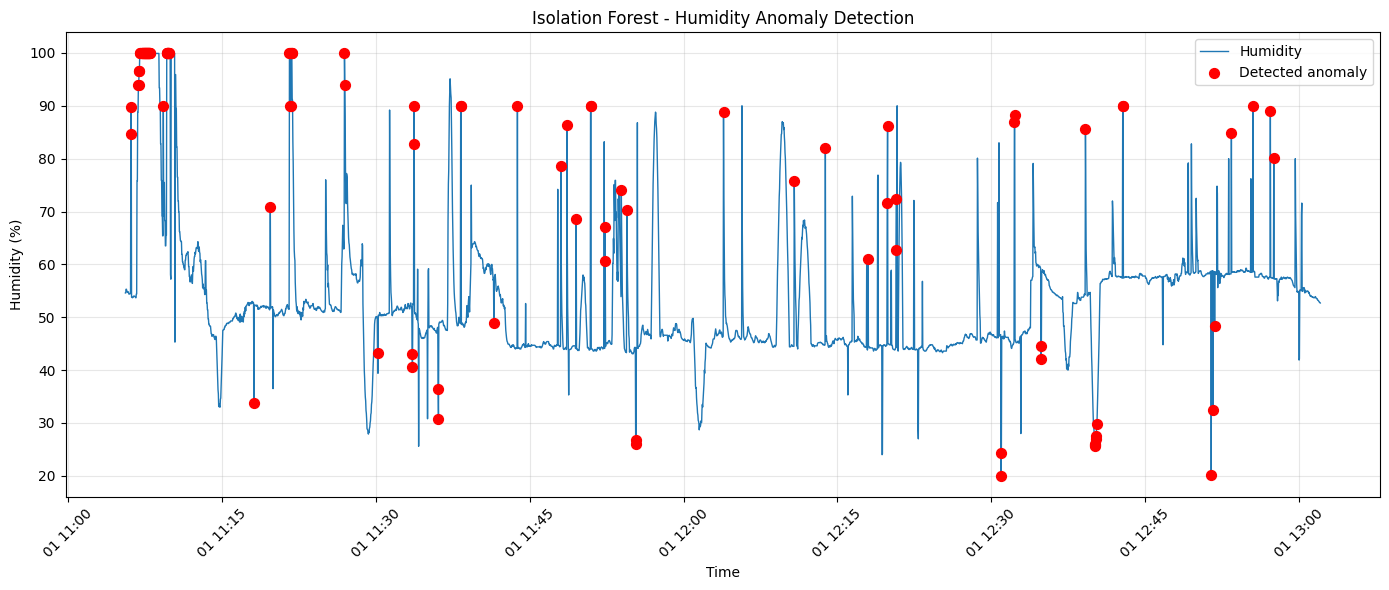

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import joblib
import os

# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("data.csv")


# ============================================================
# 2. CREATE TIMESTAMP
# ============================================================

df["timestamp"] = pd.to_datetime(
    df["horaire"],
    format="%H:%M:%S"
)


# ============================================================
# 3. FEATURES
# ============================================================

FEATURES = [
    "temperature_C",
    "humidite_pct"
]

X = df[FEATURES]


# ============================================================
# 4. TRAIN ISOLATION FOREST
# ============================================================

model = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)

model.fit(X)


# ============================================================
# 5. SAVE COMPLETE MODEL
# ============================================================

model_package = {
    "model": model,
    "features": FEATURES,
    "contamination": 0.03,
    "n_estimators": 200,
    "random_state": 42
}

joblib.dump(
    model_package,
    "isolation_forest_model.joblib"
)

print("\nModel saved successfully!")
print("File: isolation_forest_model.joblib")


# ============================================================
# 6. PREDICTIONS ON TRAINING DATA
# ============================================================

df["prediction"] = model.predict(X)

df["anomaly"] = (
    df["prediction"] == -1
).astype(int)


# ============================================================
# 7. ANOMALY SCORE
# ============================================================

df["anomaly_score"] = -model.score_samples(X)


# ============================================================
# 8. RESULTS
# ============================================================

print("\n======================================")
print("       ISOLATION FOREST RESULTS")
print("======================================")

print("Number of observations:", len(df))

print(
    "Detected anomalies:",
    df["anomaly"].sum()
)

print(
    "Anomaly rate:",
    round(df["anomaly"].mean() * 100, 2),
    "%"
)


# ============================================================
# 9. TEMPERATURE GRAPH
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    df["timestamp"],
    df["temperature_C"],
    linewidth=1,
    label="Temperature"
)

anomalies = df[df["anomaly"] == 1]

plt.scatter(
    anomalies["timestamp"],
    anomalies["temperature_C"],
    marker="o",
    color="red",
    s=50,
    label="Detected anomaly",
    zorder=5
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.title(
    "Isolation Forest - Temperature Anomaly Detection"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 10. HUMIDITY GRAPH
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    df["timestamp"],
    df["humidite_pct"],
    linewidth=1,
    label="Humidity"
)

plt.scatter(
    anomalies["timestamp"],
    anomalies["humidite_pct"],
    marker="o",
    color="red",
    s=50,
    label="Detected anomaly",
    zorder=5
)

plt.xlabel("Time")
plt.ylabel("Humidity (%)")

plt.title(
    "Isolation Forest - Humidity Anomaly Detection"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 11. SAVE TRAINING RESULTS
# ============================================================

df.to_csv(
    "isolation_forest_results.csv",
    index=False
)

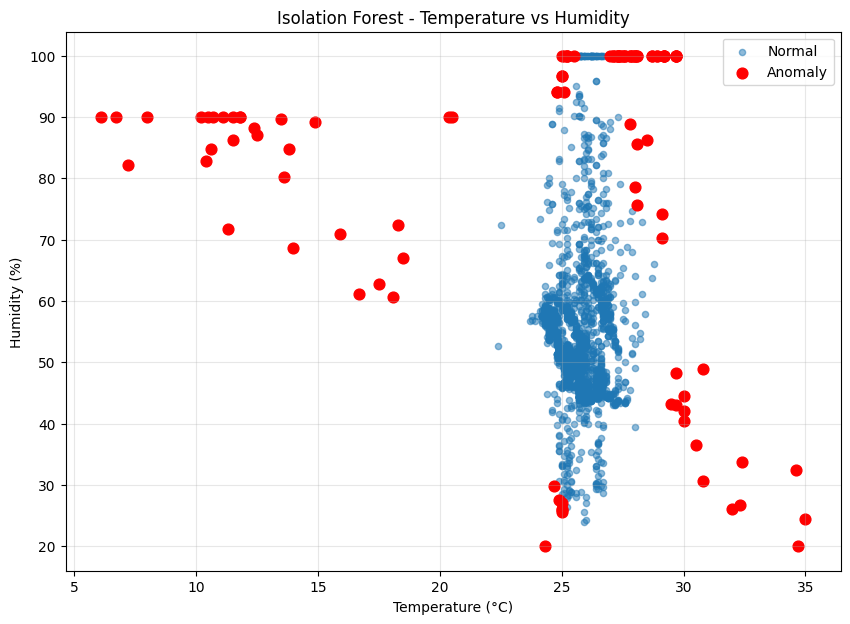

In [2]:
plt.figure(figsize=(10, 7))

normal = df[df["anomaly"] == 0]
anomalies = df[df["anomaly"] == 1]

plt.scatter(
    normal["temperature_C"],
    normal["humidite_pct"],
    s=20,
    alpha=0.5,
    label="Normal"
)

plt.scatter(
    anomalies["temperature_C"],
    anomalies["humidite_pct"],
    color="red",
    s=60,
    label="Anomaly"
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.title("Isolation Forest - Temperature vs Humidity")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

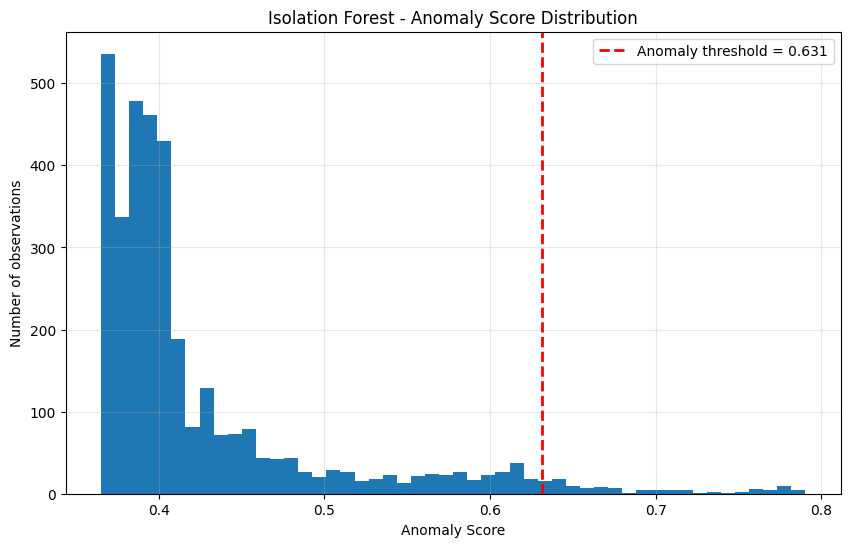

In [3]:
threshold = -model.offset_

plt.figure(figsize=(10, 6))

plt.hist(
    df["anomaly_score"],
    bins=50
)

plt.axvline(
    threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Anomaly threshold = {threshold:.3f}"
)

plt.xlabel("Anomaly Score")
plt.ylabel("Number of observations")
plt.title("Isolation Forest - Anomaly Score Distribution")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

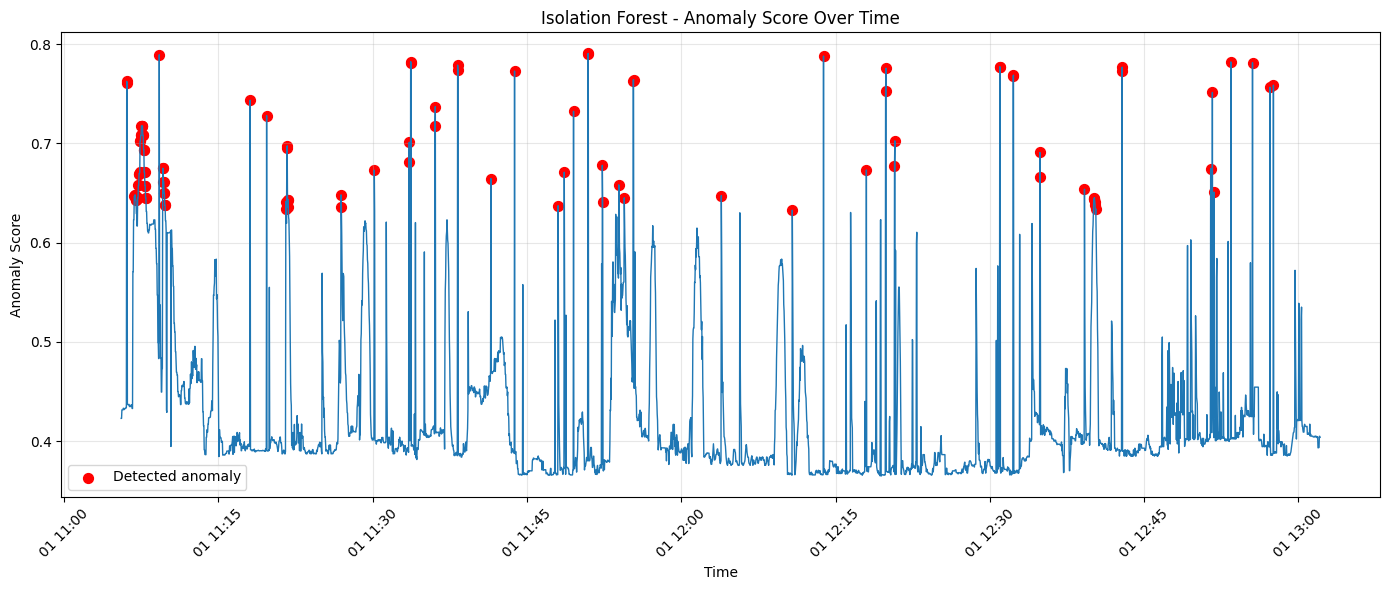

In [4]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["timestamp"],
    df["anomaly_score"],
    linewidth=1
)

plt.scatter(
    anomalies["timestamp"],
    anomalies["anomaly_score"],
    color="red",
    s=50,
    label="Detected anomaly"
)

plt.xlabel("Time")
plt.ylabel("Anomaly Score")
plt.title("Isolation Forest - Anomaly Score Over Time")

plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [5]:
for contamination in [0.03, 0.05]:

    model_test = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=42
    )

    model_test.fit(X)

    scores = -model_test.score_samples(X)

    threshold = -model_test.offset_

    print(
        f"Contamination: {contamination*100:.0f}%"
    )
    print(
        f"Threshold: {threshold:.3f}"
    )
    print(
        f"Anomalies: {(model_test.predict(X) == -1).sum()}"
    )
    print()

Contamination: 3%
Threshold: 0.631
Anomalies: 105

Contamination: 5%
Threshold: 0.611
Anomalies: 175

